# PlantaIa — análisis ampliado (práctica posterior a la Tarea 1)

**Qué es este cuaderno.** La devolución de la primera entrega pidió dos cosas: más datos etiquetados de forma manual y no arrastrados, y un análisis que relacione los patrones con lo que le pasa a la planta en vez de limitarse a describirlos. Este notebook retoma ambas. El `01_eda.ipynb` entregado no se modificó.

> **Advertencia sobre el origen de los datos.** Hay dos fuentes y nunca deben mezclarse en una conclusión sobre la planta:
>
> * **`real`** — lo que midió la placa `maceta-01`: 12 al 17/09 y 1 al 3/10.
> * **`simulado`** — `maceta-sim`, generado con un script local para practicar con los días en que no se registró (23/09 al 30/09 y 3 al 8/10). **No son mediciones.** Se construyeron con una regla conocida (el sustrato se seca, se riega y la planta cambia de estado con retardo), así que sirven para probar *métodos*, no para aprender nada sobre el lirio de paz.

Para cada resultado se indica de qué fuente sale. Cuando el simulado "acierta", lo hace porque la regla está escrita en el generador: eso valida la herramienta de análisis, no la hipótesis.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.patches import Patch
from scipy import stats
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from sklearn.model_selection import GroupKFold, StratifiedKFold, cross_val_predict

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", context="notebook")

RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data").is_dir())
DATOS, SALIDAS = RAIZ / "data", RAIZ / "outputs"
SALIDAS.mkdir(exist_ok=True)

CLASES = ["saludable", "estresada", "marchita"]
COLORES = {"saludable": "#4c9f70", "estresada": "#e6a23c", "marchita": "#c84b4b"}
VARIABLES = {
    "luz_mv": "Luz (mV)",
    "temperatura_c": "Temperatura del aire (°C)",
    "humedad_ambiente_pct": "Humedad del aire (%)",
    "suelo_mv": "Sustrato (mV; mayor = más seco)",
}
V = list(VARIABLES)
RIEGOS = pd.to_datetime(["2026-09-26 12:50", "2026-09-30 06:00", "2026-10-07 12:40"], utc=True)

## 1. Carga y construcción del dataset

Cada fila se cruza con `data/episodios.csv`: la etiqueta de análisis es la del **episodio** que contiene la fila, no la que mandó la placa fila a fila. El snapshot de la base (`mediciones_raw_2026-10-08.csv`) trae solo la placa real. Las simuladas se leen de su propio CSV, que conserva además el estado real que usó el generador.

In [2]:
raw = pd.read_csv(DATOS / "mediciones_raw_2026-10-08.csv", parse_dates=["ts_dispositivo"])
episodios = pd.read_csv(DATOS / "episodios.csv", parse_dates=["ts_inicio", "ts_fin"])

# Placa real: solo maceta-01 y solo desde el primer episodio etiquetado (12/09).
# Las simuladas se leen de su propio CSV, que trae además el estado
# "verdadero" que el simulador usó para generarlas.
real = raw[(raw.dispositivo == "maceta-01") & (raw.ts_dispositivo >= "2026-09-12")].copy()
real = real.rename(columns={"ts_dispositivo": "ts"})
sim = pd.read_csv(DATOS / "simulados_2026-09-23_a_10-08.csv")
sim["ts"] = pd.to_datetime(sim.ts_dispositivo, unit="s", utc=True)

def asignar_episodio(df, disp):
    """Cruza cada fila con el intervalo [ts_inicio, ts_fin) que la contiene."""
    ep = np.full(len(df), np.nan)
    clase = np.full(len(df), None, dtype=object)
    origen = np.full(len(df), None, dtype=object)
    for _, e in episodios[episodios.dispositivo == disp].iterrows():
        m = ((df.ts >= e.ts_inicio) & (df.ts < e.ts_fin)).values
        ep[m], clase[m], origen[m] = e.episodio_id, e.clase, e.origen
    return df.assign(episodio=ep, etiqueta=clase, origen_ep=origen)

real = asignar_episodio(real, "maceta-01").assign(fuente="real", estado_real=None)
sim = asignar_episodio(sim, "maceta-sim").assign(fuente="simulado", estado_real=sim.estado_real_simulado)

cols = ["ts", "fuente", "episodio", "etiqueta", "origen_ep", "estado_real", "boot_id", *V]
datos = pd.concat([real[cols], sim[cols]], ignore_index=True)
sin_episodio = datos.episodio.isna().sum()
datos = datos.dropna(subset=["episodio", *V]).copy()
datos["etiqueta"] = pd.Categorical(datos.etiqueta, categories=CLASES, ordered=True)
datos["hora_local"] = (datos.ts + pd.Timedelta(hours=-3)).dt.hour
datos["es_noche"] = ~datos.hora_local.between(7, 19)
print(f"filas descartadas (fuera de todo episodio o con una variable en null): {sin_episodio:,}")

def resumen(g):
    dt = g.ts.sort_values().diff().dt.total_seconds()
    return pd.Series({
        "filas": len(g),
        "días con datos": g.ts.dt.date.nunique(),
        "horas efectivas": dt.where(dt <= 900, 0).sum() / 3600,
        "episodios": g.episodio.nunique(),
        "episodios manuales": g[g.origen_ep == "manual"].episodio.nunique(),
        "episodios propagados": g[g.origen_ep == "propagada"].episodio.nunique(),
        "episodios corregidos": g[g.origen_ep == "corregida"].episodio.nunique(),
    })
control = datos.groupby("fuente").apply(resumen, include_groups=False)
display(control)
display(pd.crosstab([datos.fuente, datos.etiqueta], datos.origen_ep))

filas descartadas (fuera de todo episodio o con una variable en null): 29


,filas,días con datos,horas efectivas,episodios,episodios manuales,episodios propagados,episodios corregidos
fuente,,,,,,,
real,"6,496.00",8.00,54.92,10.00,7.00,2.00,1.00
simulado,"4,248.00",15.00,286.97,48.00,46.00,2.00,0.00


origen_ep           corregida  manual  propagada
fuente   etiqueta                               
real     saludable          0    1769          0
         estresada          0    1742         21
         marchita        1542    1325         97
simulado saludable          0    2156         82
         estresada          0    1809          0
         marchita           0     201          0

## 2. La tanda real del 1 al 3 de octubre

In [3]:
real_nuevo = real[real.ts >= "2026-10-01"].copy()
real_nuevo["dt"] = real_nuevo.ts.diff().dt.total_seconds()
huecos = real_nuevo[real_nuevo.dt > 900][["ts", "dt", "boot_id"]].assign(horas=lambda d: d.dt / 3600)
print("Huecos > 15 min en la tanda real del 1–3/10 (cada uno es un corte de luz o de WiFi):")
display(huecos[["ts", "horas", "boot_id"]].round(2))
print("Avisos de los sensores en esa tanda:")
display(real_nuevo.errores.fillna("ninguno").value_counts().to_frame("filas"))
print("Primeras filas de la tanda (sonda de suelo recién colocada):")
display(real_nuevo[["ts", "suelo_mv", "condicion_etiqueta", "etiqueta_origen", "errores"]].head(6))

Huecos > 15 min en la tanda real del 1–3/10 (cada uno es un corte de luz o de WiFi):


,ts,horas,boot_id
4761,2026-10-02 00:50:41+00:00,9.64,46
5028,2026-10-02 11:13:08+00:00,8.15,47
5564,2026-10-03 12:36:19+00:00,20.92,48


Avisos de los sensores en esa tanda:


,filas
errores,
ninguno,2430
luz_saturada,1056
suelo_saturado,3


Primeras filas de la tanda (sonda de suelo recién colocada):


,ts,suelo_mv,condicion_etiqueta,etiqueta_origen,errores
3034,2026-10-01 00:39:57+00:00,"3,124.00",marchita,manual,suelo_saturado
3035,2026-10-01 00:40:27+00:00,"3,124.00",marchita,propagada,suelo_saturado
3036,2026-10-01 00:40:57+00:00,"3,124.00",marchita,propagada,suelo_saturado
3037,2026-10-01 00:41:27+00:00,"1,936.00",marchita,propagada,NaN
3038,2026-10-01 00:41:57+00:00,"1,845.00",marchita,propagada,NaN
3039,2026-10-01 00:42:27+00:00,"2,012.00",marchita,propagada,NaN


**Qué cambió respecto de la primera entrega.** El dataset real pasa de 7 a 10 episodios, ahora con 7 anclados por una pulsación del botón (`manual`), y se suman tres días de calendario distintos. Sigue siendo muy poco: 10 episodios es el N efectivo, no las 6.496 filas.

**Calidad de la tanda nueva (3.489 filas).**

* Hay tres huecos de 8 a 21 horas, cada uno con un `boot_id` nuevo: son reinicios de la placa. La serie no es continua y el episodio `estresada` del 1/10 y el `saludable` del 2/10 cruzan un hueco.
* 1.056 filas (30 %) llevan `luz_saturada`: el LDR está en el techo del ADC durante las horas de sol. La luz no distingue entre un día claro y uno muy claro.
* Las tres primeras filas tienen `suelo_saturado` (3.124 mV): la sonda todavía no estaba clavada en el sustrato. La pulsación `marchita` de la muestra 3034 se hizo justo en ese momento.

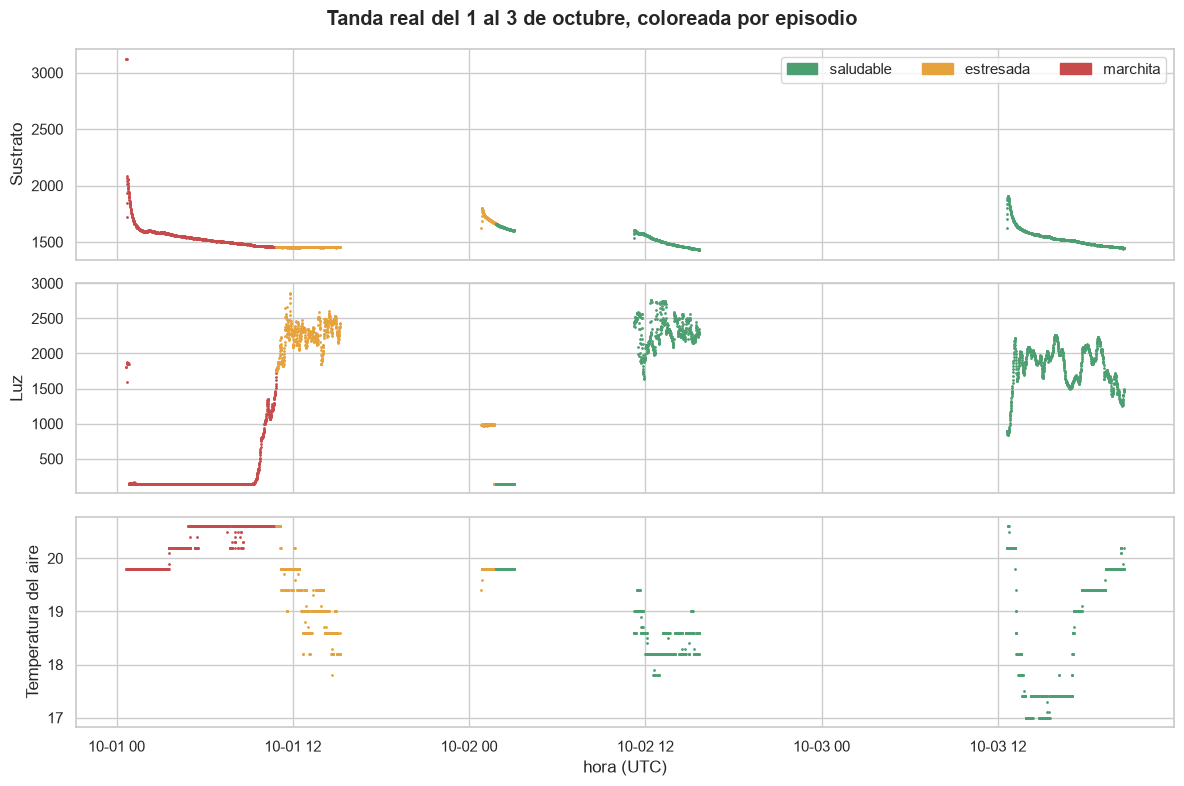

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
rn = datos[(datos.fuente == "real") & (datos.ts >= "2026-10-01")]
for ax, col in zip(axes, ["suelo_mv", "luz_mv", "temperatura_c"]):
    for e, tramo in rn.groupby("episodio"):
        ax.plot(tramo.ts, tramo[col], ".", ms=2, color=COLORES[str(tramo.etiqueta.iloc[0])])
    ax.set_ylabel(VARIABLES[col].split(" (")[0])
axes[-1].set_xlabel("hora (UTC)")
axes[0].legend(handles=[Patch(color=COLORES[c], label=c) for c in CLASES], loc="upper right", ncol=3)
fig.suptitle("Tanda real del 1 al 3 de octubre, coloreada por episodio", fontweight="bold")
fig.tight_layout()
fig.savefig(SALIDAS / "14_tanda_real_octubre.png", dpi=150, bbox_inches="tight")
plt.show()

**Lo que muestra la tanda real.**

1. **La primera etiqueta es dudosa.** El episodio `marchita` del 1/10 transcurre de noche (luz ≈ 146 mV, la oscuridad del LDR) y con el sustrato en ~1.550 mV. En septiembre la `marchita` tenía el sustrato en ~2.700 mV y la `saludable` en ~1.800–2.200. En esta tanda el promedio del sustrato es casi idéntico en las tres clases (1.500 / 1.547 / 1.534 mV para `estresada` / `marchita` / `saludable`): **el sustrato no separa nada**. O la planta no estaba marchita, o la sonda no mide lo que se cree; sin la foto de la ESP32-CAM de esa hora no se puede decidir y por eso la nota del episodio 8 lo marca como etiqueta a revisar.
2. **El sustrato decae como una exponencial después de cada reinicio** (≈ 2.000 → 1.450 mV el 1/10; ≈ 1.800 → 1.600 el 2/10; ≈ 1.900 → 1.450 el 3/10). Una planta no se rehidrata tres veces en tres días sin riego registrado. Es más probable que sea un transitorio de la sonda resistiva o del arranque de la placa (hipótesis, no verificada). Si es así, parte de la variación del sustrato mide el dispositivo y no la planta, algo que el protocolo ya advertía y que justifica registrar cada riego aparte.
3. **Luz y temperatura siguen al reloj, no a la planta.** La luz sube a media mañana y la temperatura del aire se mueve entre 17 y 20,6 °C según la hora; la clase cambia en las mismas horas porque la persona observó en esas horas.

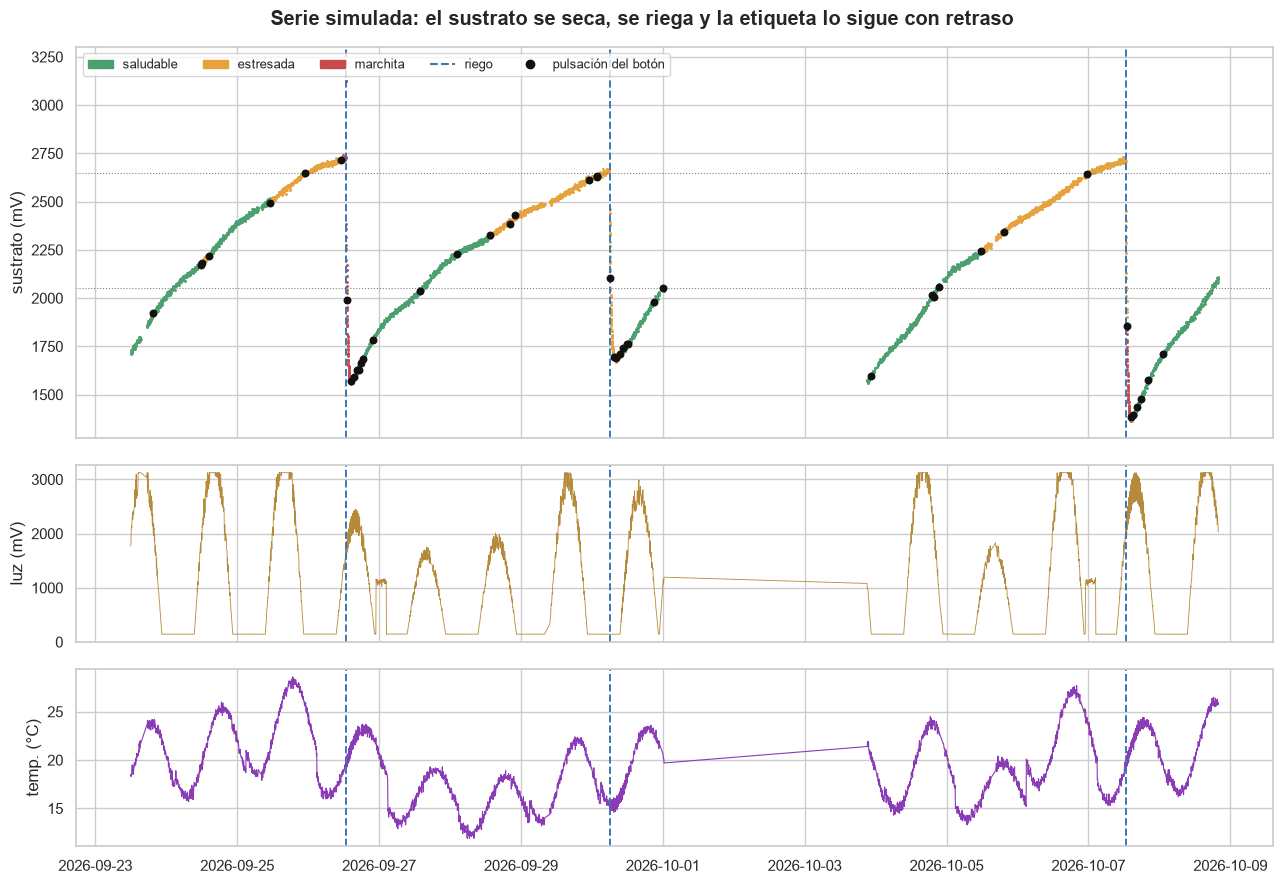

In [5]:
sm = datos[datos.fuente == "simulado"].sort_values("ts")
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True, gridspec_kw={"height_ratios": [2.2, 1, 1]})
ax = axes[0]
for e, tramo in sm.groupby("episodio"):
    ax.plot(tramo.ts, tramo.suelo_mv, ".", ms=2.2, color=COLORES[str(tramo.etiqueta.iloc[0])])
pulsos = sm[sm.origen_ep == "manual"].groupby("episodio").first()
ax.scatter(pulsos.ts, pulsos.suelo_mv, color="#111", s=22, zorder=5, label="pulsación del botón")
for r in RIEGOS:
    ax.axvline(r, color="#3b78b5", ls="--", lw=1.4)
ax.axhline(2050, color="gray", lw=0.8, ls=":"); ax.axhline(2650, color="gray", lw=0.8, ls=":")
ax.set_ylabel("sustrato (mV)")
axes[1].plot(sm.ts, sm.luz_mv, lw=0.6, color="#b58b3b"); axes[1].set_ylabel("luz (mV)")
axes[2].plot(sm.ts, sm.temperatura_c, lw=0.8, color="#8b3bb5"); axes[2].set_ylabel("temp. (°C)")
for r in RIEGOS:
    for a in axes[1:]: a.axvline(r, color="#3b78b5", ls="--", lw=1.4)
ax.legend(handles=[Patch(color=COLORES[c], label=c) for c in CLASES]
          + [plt.Line2D([], [], color="#3b78b5", ls="--", label="riego"),
             plt.Line2D([], [], marker="o", ls="", color="#111", label="pulsación del botón")],
          loc="upper left", ncol=5, fontsize=9)
ax.set_ylim(top=3300)
fig.suptitle("Serie simulada: el sustrato se seca, se riega y la etiqueta lo sigue con retraso",
             fontweight="bold")
fig.tight_layout()
fig.savefig(SALIDAS / "15_simulado_sustrato_riegos.png", dpi=150, bbox_inches="tight")
plt.show()

**Cómo se ve el mecanismo en el simulado.** El sustrato sube (se seca) de forma continua hasta cada riego —líneas azules— y cae a ~1.300–1.650 mV de golpe; la planta pasa de `saludable` a `estresada` cuando el sustrato supera ≈ 2.050 mV y a `marchita` pasados ≈ 2.650 mV, con un retardo de varias horas. La etiqueta que viaja, en cambio, solo cambia cuando alguien aprieta el botón (puntos negros), de modo que entre pulsaciones queda "congelada". Es el mismo problema de las etiquetas arrastradas que marcó la profesora, ahora medible porque en el simulado sí se conoce el estado verdadero.

In [6]:
tabla = pd.crosstab(sm.etiqueta, sm.estado_real, normalize="index").reindex(index=CLASES, columns=CLASES).fillna(0) * 100
display(tabla.round(1).rename_axis("etiqueta que viaja", axis=0).rename_axis("estado real simulado", axis=1))
print(f"Filas con etiqueta distinta del estado real: {(sm.etiqueta.astype(str) != sm.estado_real).mean():.1%}")

# ¿Cuántas horas queda la etiqueta desfasada en las 12 h posteriores a cada riego?
sm["dur_h"] = sm.ts.diff().shift(-1).dt.total_seconds().clip(upper=900).fillna(0) / 3600
filas = []
for r in RIEGOS[(RIEGOS >= sm.ts.min()) & (RIEGOS <= sm.ts.max())]:
    despues = sm[(sm.ts >= r) & (sm.ts < r + pd.Timedelta(hours=12))]
    mal = despues.etiqueta.astype(str) != despues.estado_real
    filas.append({"riego": r, "horas observadas": despues.dur_h.sum(),
                  "horas con etiqueta desfasada": despues.loc[mal, "dur_h"].sum()})
display(pd.DataFrame(filas).round(1))

estado real simulado,saludable,estresada,marchita
etiqueta que viaja,,,
saludable,74.20,25.80,0.00
estresada,9.20,84.00,6.70
marchita,0.00,82.60,17.40


Filas con etiqueta distinta del estado real: 24.3%


,riego,horas observadas,horas con etiqueta desfasada
0,2026-09-26 12:50:00+00:00,11.80,2.30
1,2026-09-30 06:00:00+00:00,12.10,1.80
2,2026-10-07 12:40:00+00:00,12.00,1.90


**Cuánto se equivoca una etiqueta arrastrada (simulado).** En el 24,3 % de las filas la etiqueta que viaja difiere del estado de la planta. Casi todo el error es retardo y no ruido: tras cada riego la etiqueta queda desfasada entre 1,8 y 2,3 de las siguientes 12 h, porque la planta se recupera antes de que alguien lo registre. Además la clase `marchita` casi no existe en el simulado (201 filas, 4,7 %) y solo el 17,4 % de esas filas corresponde a una planta realmente marchita: las observaciones hechas cerca de un umbral caen del lado equivocado con frecuencia.

Lección práctica: las pulsaciones del botón hay que concentrarlas en los momentos en que la planta *cambia* (antes y después de un riego, cuando aparece una hoja caída) y no repartirlas a horas fijas.

## 3. ¿La etiqueta describe a la planta o al reloj?

,"real, todo","real, sin etiqueta corregida",simulado
Luz (mV),0.35,0.34,0.03
Temperatura del aire (°C),0.02,0.24,0.01
Humedad del aire (%),0.23,0.09,0.01
Sustrato (mV; mayor = más seco),0.17,0.09,0.23


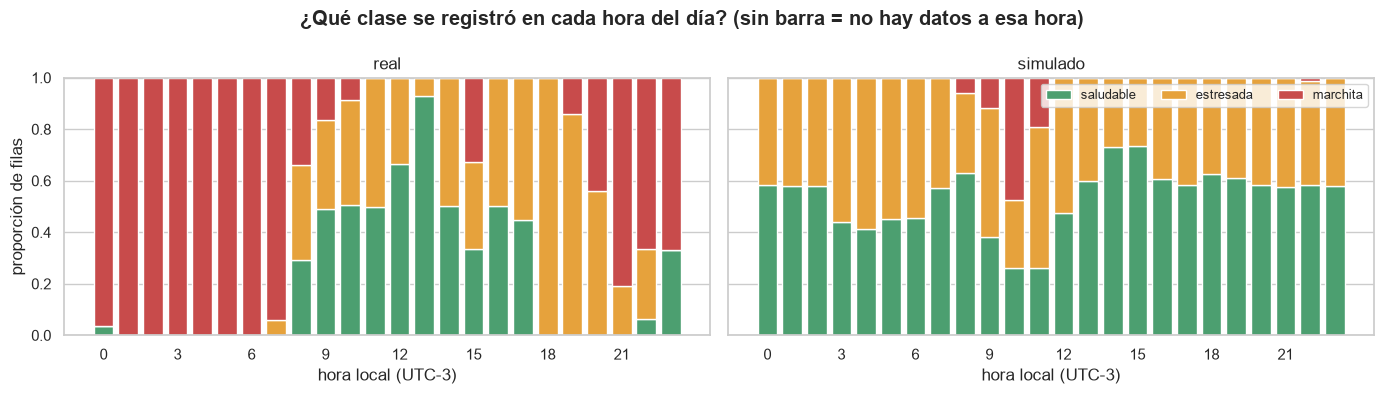

V de Cramér entre 'es de noche' y la clase: {'real': np.float64(0.7), 'simulado': np.float64(0.19)}


In [7]:
def eps2(d, col):
    grupos = [d.loc[d.etiqueta == c, col].dropna() for c in CLASES]
    grupos = [g for g in grupos if len(g) > 1]
    H, _ = stats.kruskal(*grupos)
    return (H - len(grupos) + 1) / (len(d) - len(grupos))

conjuntos = {
    "real, todo": datos[datos.fuente == "real"],
    "real, sin etiqueta corregida": datos[(datos.fuente == "real") & (datos.origen_ep != "corregida")],
    "simulado": datos[datos.fuente == "simulado"],
}
tam = pd.DataFrame({n: {VARIABLES[c]: eps2(d, c) for c in V} for n, d in conjuntos.items()})
display(tam.round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)
for ax, (n, d) in zip(axes, [("real", datos[datos.fuente == "real"]), ("simulado", datos[datos.fuente == "simulado"])]):
    p = pd.crosstab(d.hora_local, d.etiqueta).reindex(index=range(24), columns=CLASES).fillna(0)
    p = p.div(p.sum(axis=1).replace(0, np.nan), axis=0)
    ax.bar(p.index, p.saludable.fillna(0), color=COLORES["saludable"], label="saludable")
    ax.bar(p.index, p.estresada.fillna(0), bottom=p.saludable.fillna(0), color=COLORES["estresada"], label="estresada")
    ax.bar(p.index, p.marchita.fillna(0), bottom=(p.saludable + p.estresada).fillna(0), color=COLORES["marchita"], label="marchita")
    ax.set_title(n); ax.set_xlabel("hora local (UTC-3)"); ax.set_xticks(range(0, 24, 3))
axes[0].set_ylabel("proporción de filas"); axes[1].legend(loc="upper right", ncol=3, fontsize=9)
fig.suptitle("¿Qué clase se registró en cada hora del día? (sin barra = no hay datos a esa hora)", fontweight="bold")
fig.tight_layout()
fig.savefig(SALIDAS / "16_clase_por_hora.png", dpi=150, bbox_inches="tight")
plt.show()

def cramer(d):
    t = pd.crosstab(d.es_noche, d.etiqueta)
    chi2 = stats.chi2_contingency(t)[0]
    return np.sqrt(chi2 / (t.values.sum() * (min(t.shape) - 1)))
print("V de Cramér entre 'es de noche' y la clase:",
      {n: round(cramer(d), 2) for n, d in [("real", datos[datos.fuente == "real"]), ("simulado", datos[datos.fuente == "simulado"])]})

**Confusión entre clase y hora del día.**

* **Real:** casi todas las filas de la noche (0 a 7 h) son `marchita` y casi todas las diurnas son `saludable` o `estresada`. La asociación entre "es de noche" y la clase es fuerte (V de Cramér = 0,70). La luz tiene el mayor efecto (ε² = 0,35) pero eso es el ciclo día/noche: la planta no se marchita por la noche. Al agregar la tanda de octubre, el efecto aparente de la temperatura cayó de 0,45 (primera entrega) a 0,02, porque ahora las tres clases se observaron a temperaturas parecidas; sin la etiqueta corregida sube a 0,24, lo que muestra lo inestable que es con 7 u 8 episodios.
* **Simulado:** la clase queda repartida en todas las horas (V = 0,19) y los efectos de luz, temperatura y humedad del aire son casi nulos (ε² ≤ 0,03). El único con efecto es el sustrato (ε² = 0,23), que es exactamente la variable con la que se escribió la regla.

Esto es lo que el diseño de recolección tiene que lograr: observar **cada clase en distintas horas y días** para que el reloj deje de explicar la etiqueta.

## 4. Validación: partición aleatoria frente a partición por episodio

Se entrenó un Random Forest (300 árboles) con cada subconjunto de variables y se midió la exactitud balanceada (el azar con 3 clases es 0,33) con dos esquemas: `StratifiedKFold` mezclando filas, y `GroupKFold` dejando cada episodio entero fuera del entrenamiento.

In [8]:
def evaluar(d, cols, grupos_por_episodio):
    X, y, g = d[cols].values, d.etiqueta.astype(str).values, d.episodio.values
    modelo = RandomForestClassifier(300, min_samples_leaf=5, random_state=0, n_jobs=-1)
    cv = (GroupKFold(n_splits=min(5, d.episodio.nunique())) if grupos_por_episodio
          else StratifiedKFold(5, shuffle=True, random_state=0))
    pred = cross_val_predict(modelo, X, y, cv=cv, groups=g if grupos_por_episodio else None)
    return balanced_accuracy_score(y, pred), pred

filas, preds = [], {}
for fuente in ["real", "simulado"]:
    d = datos[datos.fuente == fuente]
    for nombre, cols in [("las 4 variables", V), ("solo sustrato", ["suelo_mv"]),
                         ("sin sustrato (luz, temp., humedad)", ["luz_mv", "temperatura_c", "humedad_ambiente_pct"])]:
        for grupos in (False, True):
            acc, pred = evaluar(d, cols, grupos)
            filas.append({"datos": fuente, "variables": nombre,
                          "partición": "por episodio" if grupos else "aleatoria",
                          "exactitud balanceada": acc})
            preds[(fuente, nombre, grupos)] = (d.etiqueta.astype(str).values, pred)
resultados = pd.DataFrame(filas)
display(resultados.pivot_table(index=["datos", "variables"], columns="partición",
                               values="exactitud balanceada").round(3))

partición                                    aleatoria  por episodio
datos    variables                                                  
real     las 4 variables                          1.00          0.05
         sin sustrato (luz, temp., humedad)       0.99          0.04
         solo sustrato                            0.79          0.15
simulado las 4 variables                          0.89          0.59
         sin sustrato (luz, temp., humedad)       0.73          0.35
         solo sustrato                            0.59          0.47

**Resultado.**

| datos | variables | partición aleatoria | por episodio |
|---|---|---|---|
| real | las 4 | 1,00 | 0,05 |
| real | solo sustrato | 0,79 | 0,15 |
| simulado | las 4 | 0,89 | 0,59 |
| simulado | sin sustrato | 0,73 | 0,35 |
| simulado | solo sustrato | 0,59 | 0,47 |

* **Real.** Con filas mezcladas el modelo "acierta" el 100 %; con episodios completos fuera, el 5 %, por debajo del azar. Con solo 10 episodios y cada clase concentrada en pocos de ellos, lo que el modelo aprende es *a qué episodio pertenece una fila* (por la hora, la luz, la temperatura de ese día), no la condición de la planta. Es el leakage descrito en el CLAUDE.md y acá se ve con números.
* **Simulado.** Con 48 episodios la caída es mucho menor (0,89 → 0,59) y, validando bien, **el sustrato solo (0,47) supera a luz + temperatura + humedad juntas (0,35, apenas sobre el azar)**. Eso es lo que se espera por construcción; confirma que la validación por grupos distingue una señal causal de una confundida con el tiempo, no que el lirio de paz se comporte así.

Las matrices de confusión lo confirman: en el real el modelo no acierta ninguna fila `saludable` (las manda a `estresada`) y casi ninguna `marchita`; en el simulado `marchita` se acierta solo en 49 de 201 filas (24 %), porque tiene muy pocos episodios.

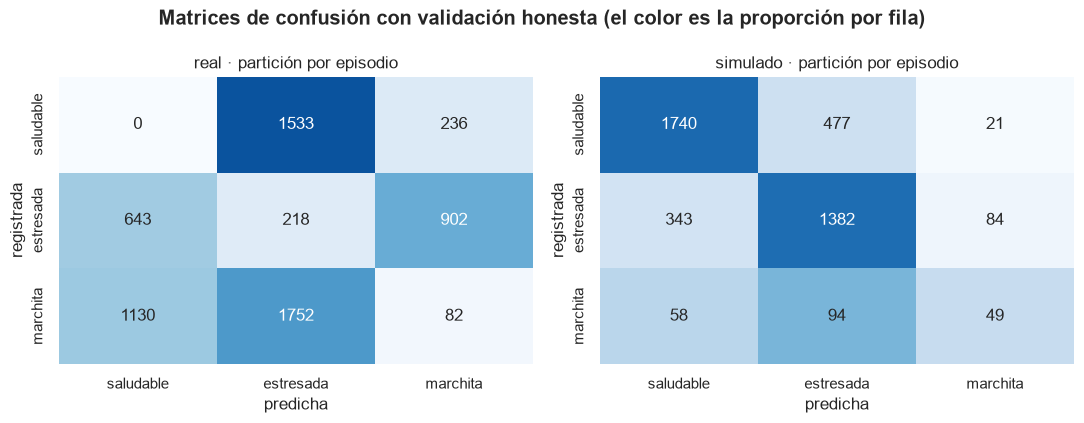

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.3))
for ax, fuente in zip(axes, ["real", "simulado"]):
    y, p = preds[(fuente, "las 4 variables", True)]
    cm = confusion_matrix(y, p, labels=CLASES)
    sns.heatmap(cm / cm.sum(axis=1, keepdims=True).clip(1), annot=cm, fmt="d", cmap="Blues", vmin=0, vmax=1,
                xticklabels=CLASES, yticklabels=CLASES, cbar=False, ax=ax)
    ax.set(title=f"{fuente} · partición por episodio", xlabel="predicha", ylabel="registrada")
fig.suptitle("Matrices de confusión con validación honesta (el color es la proporción por fila)", fontweight="bold")
fig.tight_layout()
fig.savefig(SALIDAS / "17_confusion_por_episodio.png", dpi=150, bbox_inches="tight")
plt.show()

## 5. Conclusiones

1. **Más datos manuales.** El dataset real tiene ahora 10 episodios (7 anclados en una observación) frente a 7, repartidos en 8 días de calendario. Sigue siendo insuficiente para entrenar: cada clase vive en pocos episodios y casi siempre a la misma hora.
2. **La etiqueta del 1/10 no es consistente con el sustrato.** Una `marchita` con el sustrato igual que `saludable` pide revisión con las fotos de la ESP32-CAM antes de usarla; hasta entonces conviene tratarla como la menos confiable de las manuales.
3. **El sustrato mezcla planta y dispositivo.** Los transitorios exponenciales tras cada reinicio no pueden ser humedad real. Hay que (a) descartar los primeros minutos después de un `boot_id` nuevo, (b) registrar cada riego y (c) seguir con la calibración semanal de la sonda resistiva.
4. **Una validación por filas miente.** 100 % con partición aleatoria frente a 5 % por episodio. Cualquier modelo que se reporte tiene que usar `GroupKFold` por episodio y declarar cuántos episodios hay.
5. **Cómo mejorar la recolección** (esto es lo que se pudo practicar con el simulado): observar y apretar el botón cuando la planta cambia, especialmente antes y después de cada riego; cubrir varios días de clima distinto; y conseguir más episodios de `marchita` sin dañar la planta, por ejemplo una ventana de secado controlada con fotos de respaldo.
6. **Límite de este cuaderno.** Todo lo que dice "simulado" está atado a las reglas del generador y no es evidencia sobre el lirio de paz. Las conclusiones sobre la planta salen solo de las filas `real`.